In [230]:
# importing python library - pandas to work with dataframe and for data handling
import numpy as np
import pandas as pd
df = pd.read_csv("loans.csv")

In [234]:
df = df.rename(columns={'Unnamed: 0': 'loan_id'})

In [236]:
# checking first five rows of the dataset
df.head()

,loan_id,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [238]:
# Checking last five rows of the dataset
df.tail()

,loan_id,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
9995,9996,owner,10.0,TX,RENT,108000.0,Source Verified,22.28,NaN,NaN,...,A4,Jan-2018,Current,whole,Cash,21586.34,2969.80,2413.66,556.14,0.0
9996,9997,director,8.0,PA,MORTGAGE,121000.0,Verified,32.38,NaN,NaN,...,D3,Feb-2018,Current,whole,Cash,9147.44,1456.31,852.56,603.75,0.0
9997,9998,toolmaker,10.0,CT,MORTGAGE,67000.0,Verified,45.26,107000.0,Source Verified,...,E2,Feb-2018,Current,fractional,Cash,27617.65,4620.80,2382.35,2238.45,0.0
9998,9999,manager,1.0,WI,MORTGAGE,80000.0,Source Verified,11.99,NaN,NaN,...,A1,Feb-2018,Current,whole,Cash,21518.12,2873.31,2481.88,391.43,0.0
9999,10000,operations analyst,3.0,CT,RENT,66000.0,Not Verified,20.82,NaN,NaN,...,B4,Feb-2018,Current,whole,Cash,11574.83,1658.56,1225.17,433.39,0.0


In [240]:
# shape of the dataset 
df.shape # there are 10000 rows and 55 columns 

(10000, 56)

In [242]:
#According to our problem statement 
# Analyze borrower, credit, and loan characteristics to identify key factors influencing loan performance and develop a rule-based risk segmentation
#                                        framework to categorize borrowers into different risk tiers.
# we need to filter columns 

In [244]:
df.columns

Index(['loan_id', 'emp_title', 'emp_length', 'state', 'homeownership',
       'annual_income', 'verified_income', 'debt_to_income',
       'annual_income_joint', 'verification_income_joint',
       'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_r

In [246]:
Final_columns =["loan_id","emp_length","state","homeownership","annual_income","verified_income","debt_to_income","delinq_2y","inquiries_last_12m"
                ,"total_credit_limit","total_credit_utilized","num_historical_failed_to_pay","public_record_bankrupt","loan_purpose","loan_amount","term"
                ,"interest_rate","grade","loan_status"]

df = df[Final_columns]

In [248]:
df.head()

,loan_id,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,inquiries_last_12m,total_credit_limit,total_credit_utilized,num_historical_failed_to_pay,public_record_bankrupt,loan_purpose,loan_amount,term,interest_rate,grade,loan_status
0,1,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0,6,70795,38767,0,0,moving,28000,60,14.07,C,Current
1,2,10.0,HI,RENT,40000.0,Not Verified,5.04,0,1,28800,4321,1,1,debt_consolidation,5000,36,12.61,C,Current
2,3,3.0,WI,RENT,40000.0,Source Verified,21.15,0,4,24193,16000,0,0,other,2000,36,17.09,D,Current
3,4,1.0,PA,RENT,30000.0,Not Verified,10.16,0,0,25400,4997,1,0,debt_consolidation,21600,36,6.72,A,Current
4,5,10.0,CA,RENT,35000.0,Verified,57.96,0,7,69839,52722,0,0,credit_card,23000,36,14.07,C,Current


In [250]:
df["loan_purpose"] = df["loan_purpose"].str.replace("_", " ")
df["loan_purpose"] = df["loan_purpose"].str.title()
df["homeownership"] = df["homeownership"].str.title()
df.head()

,loan_id,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,inquiries_last_12m,total_credit_limit,total_credit_utilized,num_historical_failed_to_pay,public_record_bankrupt,loan_purpose,loan_amount,term,interest_rate,grade,loan_status
0,1,3.0,NJ,Mortgage,90000.0,Verified,18.01,0,6,70795,38767,0,0,Moving,28000,60,14.07,C,Current
1,2,10.0,HI,Rent,40000.0,Not Verified,5.04,0,1,28800,4321,1,1,Debt Consolidation,5000,36,12.61,C,Current
2,3,3.0,WI,Rent,40000.0,Source Verified,21.15,0,4,24193,16000,0,0,Other,2000,36,17.09,D,Current
3,4,1.0,PA,Rent,30000.0,Not Verified,10.16,0,0,25400,4997,1,0,Debt Consolidation,21600,36,6.72,A,Current
4,5,10.0,CA,Rent,35000.0,Verified,57.96,0,7,69839,52722,0,0,Credit Card,23000,36,14.07,C,Current


In [252]:
df.shape # Now we have 10000 rows and 18 columns

(10000, 19)

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   loan_id                       10000 non-null  int64  
 1   emp_length                    9183 non-null   float64
 2   state                         10000 non-null  object 
 3   homeownership                 10000 non-null  object 
 4   annual_income                 10000 non-null  float64
 5   verified_income               10000 non-null  object 
 6   debt_to_income                9976 non-null   float64
 7   delinq_2y                     10000 non-null  int64  
 8   inquiries_last_12m            10000 non-null  int64  
 9   total_credit_limit            10000 non-null  int64  
 10  total_credit_utilized         10000 non-null  int64  
 11  num_historical_failed_to_pay  10000 non-null  int64  
 12  public_record_bankrupt        10000 non-null  int64  
 13  lo

# Handling Missing Values

In [256]:
df.isnull().mean()*100
# there are 817(8.17%) missing values in emp_length and 24 (0.24%)missing values in debt_to_income

loan_id                         0.00
emp_length                      8.17
state                           0.00
homeownership                   0.00
annual_income                   0.00
verified_income                 0.00
debt_to_income                  0.24
delinq_2y                       0.00
inquiries_last_12m              0.00
total_credit_limit              0.00
total_credit_utilized           0.00
num_historical_failed_to_pay    0.00
public_record_bankrupt          0.00
loan_purpose                    0.00
loan_amount                     0.00
term                            0.00
interest_rate                   0.00
grade                           0.00
loan_status                     0.00
dtype: float64

In [258]:
# filling missing values with median
df["emp_length"] = df["emp_length"].fillna(df["emp_length"].median())
df["debt_to_income"] = df["debt_to_income"].fillna(df["debt_to_income"].median())

In [260]:
df.isnull().sum()

loan_id                         0
emp_length                      0
state                           0
homeownership                   0
annual_income                   0
verified_income                 0
debt_to_income                  0
delinq_2y                       0
inquiries_last_12m              0
total_credit_limit              0
total_credit_utilized           0
num_historical_failed_to_pay    0
public_record_bankrupt          0
loan_purpose                    0
loan_amount                     0
term                            0
interest_rate                   0
grade                           0
loan_status                     0
dtype: int64

In [262]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,10000.0,5000.500000,2886.895680,1.00,2500.7500,5000.50,7500.25,10000.00
emp_length,10000.0,5.936000,3.549248,0.00,3.0000,6.00,10.00,10.00
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.00,95000.00,2300000.00
debt_to_income,10000.0,19.304020,14.987074,0.00,11.0675,17.57,24.99,469.09
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.00,0.00,13.00
inquiries_last_12m,10000.0,1.958200,2.380130,0.00,0.0000,1.00,3.00,29.00
total_credit_limit,10000.0,183606.230400,187632.707777,0.00,51593.7500,114667.00,267550.00,3386034.00
total_credit_utilized,10000.0,51049.063100,53636.731172,0.00,19185.5000,36927.00,65421.00,942456.00
num_historical_failed_to_pay,10000.0,0.167100,0.687768,0.00,0.0000,0.00,0.00,52.00
public_record_bankrupt,10000.0,0.123800,0.337172,0.00,0.0000,0.00,0.00,3.00


In [264]:
# Values 0 and 1 in annual_income were treated as invalid entries,as they do not represent realistic borrower income.

In [266]:
df["annual_income"] = df["annual_income"].replace({0: np.nan, 1: np.nan}) # replace with nan
df["annual_income"] = df["annual_income"].fillna(df["annual_income"].median())   # fill with median

In [268]:
# changing the data type of  emp_length from float64 to int64
df["emp_length"] = df["emp_length"].astype("Int64")

# Checking Duplicates

In [271]:
print("Number of Duplicate rows :",df.duplicated().sum()) # there is no duplicate value in our dataset

Number of Duplicate rows : 0


In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution

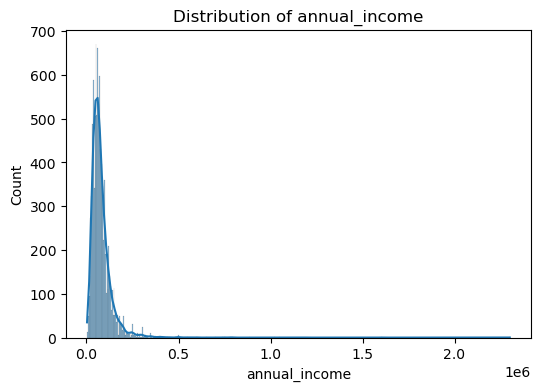

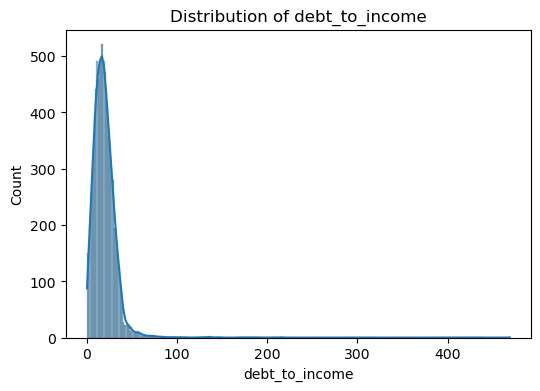

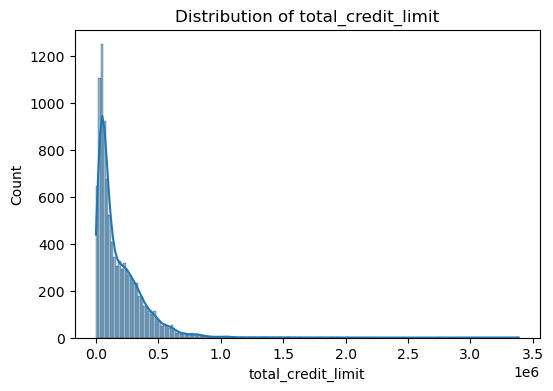

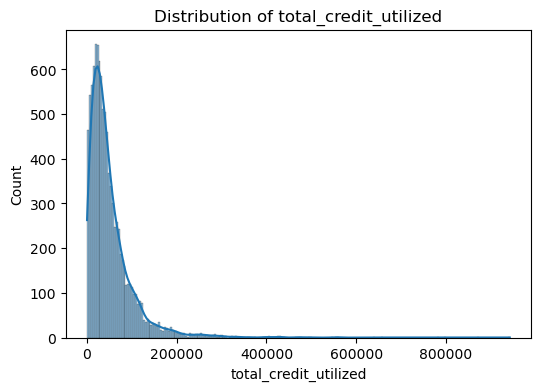

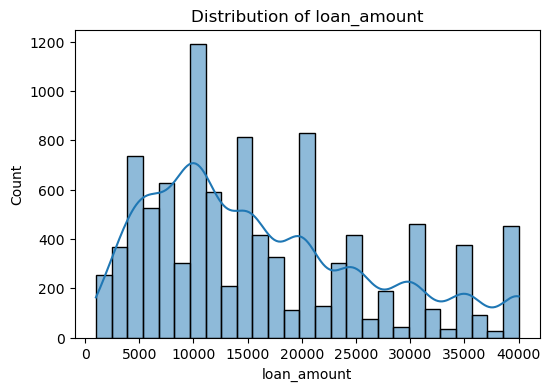

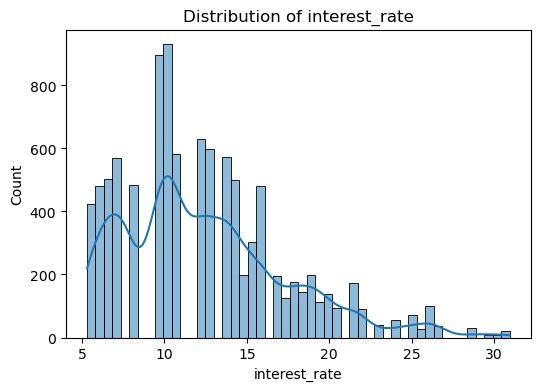

In [276]:
d_cols = ["annual_income", "debt_to_income","total_credit_limit", 
        "total_credit_utilized", "loan_amount", "interest_rate"]

for col in d_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [277]:
# from the above visualisation we can see that all columns are positively skewed 
# that is why we can use box plot to check outliers

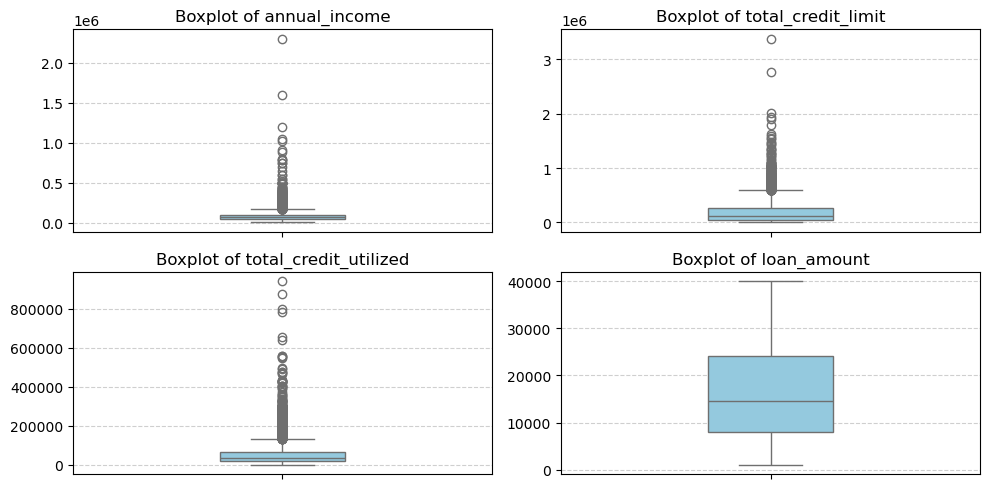

In [278]:
cols = ["annual_income","total_credit_limit", 
        "total_credit_utilized" , "loan_amount" ]

plt.figure(figsize=(10, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color="skyblue", width=0.3)
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel("")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [279]:
# there is no outliers in loan amount

# Treatment of outliers

In [281]:
outlier_cols = ["annual_income", "total_credit_limit","total_credit_utilized" ]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
              np.where(df[col] > upper_bound, upper_bound, df[col]))

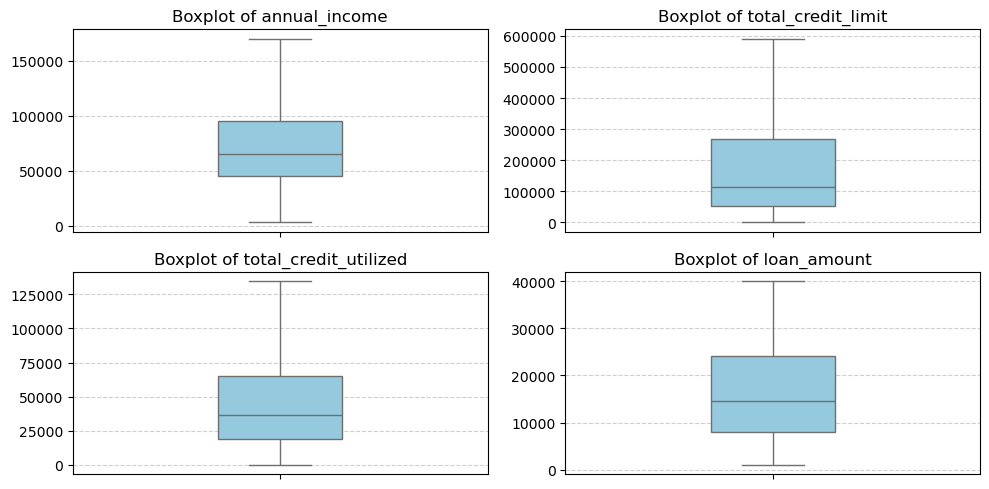

In [282]:
cols = ["annual_income","total_credit_limit", 
        "total_credit_utilized" , "loan_amount" ]

plt.figure(figsize=(10, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color="skyblue", width=0.3)
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel("")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [283]:
# The following feature engineering steps are performed to improve
# risk analysis:
# 1. risk_level: Converts loan_status into business-friendly risk categories
# 2. credit_utilization_ratio: Measures borrower credit usage intensity
# These features help identify patterns in borrower risk behavior.

In [284]:
def risk_level(x):
    if x == "Fully Paid":
        return "Low Risk"
    elif x == "Current":
        return "Medium Risk"
    elif x in ["In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]:
        return "High Risk"
    else:
        return "Default"
# adding a new column 
df["risk_level"] = df["loan_status"].apply(risk_level)

In [285]:
df["risk_level"].value_counts()

risk_level
Medium Risk    9375
Low Risk        447
High Risk       171
Default           7
Name: count, dtype: int64

In [286]:
# Values of 0 in total_credit_limit can be treated as "no credit history" that's why we keep it as it is

In [287]:
df["credit_utilization_ratio"] = np.where( df["total_credit_limit"] == 0,0,df["total_credit_utilized"] / df["total_credit_limit"])

In [288]:
df

,loan_id,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,inquiries_last_12m,total_credit_limit,...,num_historical_failed_to_pay,public_record_bankrupt,loan_purpose,loan_amount,term,interest_rate,grade,loan_status,risk_level,credit_utilization_ratio
0,1,3,NJ,Mortgage,90000.0,Verified,18.01,0,6,70795.0,...,0,0,Moving,28000,60,14.07,C,Current,Medium Risk,0.547595
1,2,10,HI,Rent,40000.0,Not Verified,5.04,0,1,28800.0,...,1,1,Debt Consolidation,5000,36,12.61,C,Current,Medium Risk,0.150035
2,3,3,WI,Rent,40000.0,Source Verified,21.15,0,4,24193.0,...,0,0,Other,2000,36,17.09,D,Current,Medium Risk,0.661348
3,4,1,PA,Rent,30000.0,Not Verified,10.16,0,0,25400.0,...,1,0,Debt Consolidation,21600,36,6.72,A,Current,Medium Risk,0.196732
4,5,10,CA,Rent,35000.0,Verified,57.96,0,7,69839.0,...,0,0,Credit Card,23000,36,14.07,C,Current,Medium Risk,0.754908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,10,TX,Rent,108000.0,Source Verified,22.28,0,5,199195.0,...,1,1,Other,24000,36,7.35,A,Current,Medium Risk,0.391390
9996,9997,8,PA,Mortgage,121000.0,Verified,32.38,4,1,382061.0,...,0,0,Debt Consolidation,10000,36,19.03,D,Current,Medium Risk,0.265850
9997,9998,10,CT,Mortgage,67000.0,Verified,45.26,2,0,346402.0,...,0,0,Debt Consolidation,30000,36,23.88,E,Current,Medium Risk,0.275463
9998,9999,1,WI,Mortgage,80000.0,Source Verified,11.99,0,1,294475.0,...,0,0,Other,24000,36,5.32,A,Current,Medium Risk,0.093865
